# Controlador integral con incertidumbre de modelo

*(Traducción a Python de `ControladorIntegral.m`, usando `numpy`, `control` y `matplotlib`)*

Diseñamos un controlador con acción integral usando el **modelo nominal** del sistema, pero lo aplicamos sobre un **sistema "real" ligeramente distinto** (con una pequeña perturbación aleatoria en $A$ y $B$), para ver cómo se comporta el controlador ante incertidumbre de modelado. La simulación se hace con integración explícita tipo Euler (no con `solve_ivp`), igual que el `.m` original usa un bucle manual en vez de `ode45`.

In [1]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)   # para reproducibilidad; el .m original no fija semilla,
                     # asi que cada ejecucion en MATLAB daria un resultado distinto

## Modelo nominal y sistema "real"

In [2]:
A = np.array([[0, 1], [0, -5]])
B = np.array([[0], [1]])
D = 0

Sistema real: igual que el modelo, pero con una pequeña perturbación aleatoria uniforme en $[0,0.1)$ en cada entrada de $A$ y $B$ (equivalente a `0.1*rand(2,2)` de MATLAB, que usa `np.random.rand` en Python — mismo rango, $[0,1)$ escalado por 0.1).

In [3]:
At = A + 0.1*np.random.rand(2, 2)
Bt = B + 0.1*np.random.rand(2, 1)
print('At =\n', At)
print('Bt =\n', Bt)

At =
 [[ 0.0375  1.0951]
 [ 0.0732 -4.9401]]
Bt =
 [[0.0156]
 [1.0156]]


## Mediciones

In [4]:
C1 = np.eye(2)          # medimos ambos estados directamente
C2 = np.array([[1, 0]])  # pero solo realimentamos con accion integral sobre x1 (posicion)

## Diseño del controlador (con las matrices del modelo, no del sistema real)

Construimos el sistema ampliado con la acción integral, igual que en los notebooks de control integral anteriores.

In [5]:
Aamp = np.block([
    [A,   np.zeros((2, 1))],
    [C2,  np.zeros((1, 1))]
])
Bamp = np.vstack([B, [[0]]])

y2d = 23   # valor deseado para la posicion

Colocamos los autovalores deseados con `control.acker` (equivalente a `acker` de MATLAB, método de Ackermann — alternativa a `place`, aunque numéricamente menos robusta para sistemas grandes o autovalores muy próximos entre sí).

**Ojo con las dimensiones:** a diferencia de `control.place`, que devuelve directamente una matriz fila `(1,n)`, `control.acker` devuelve un **array 1D**. Usamos `np.atleast_2d(...)` para forzarlo a forma de matriz fila `(1,n)`, y así poder trocearlo por columnas exactamente igual que en los notebooks anteriores.

In [6]:
lambda_des = [-1, -2, -3]   # valores propios deseados

Kamp = ct.acker(Aamp, Bamp, lambda_des)
Kamp = np.atleast_2d(Kamp)   # fuerza forma fila (1,3)
Kamp

array([[11.,  1.,  6.]])

In [7]:
K = Kamp[:, :2]    # ganancia para los estados
KI = Kamp[:, 2]     # ganancia para el error integral (queda como array 1D de 1 elemento)

print('K =', K)
print('KI =', KI)

K = [[11.  1.]]
KI = [6.]


Comprobamos que los autovalores en lazo cerrado (con el modelo nominal) son los deseados,

In [8]:
np.linalg.eigvals(Aamp - Bamp @ Kamp)

array([-3., -2., -1.])

## Simulación (integración explícita tipo Euler)

El `.m` original no usa `ode45`, sino un bucle manual con paso fijo `deltaT` — lo traducimos literalmente, ya que el objetivo aquí es mostrar el método de integración más simple posible, no la precisión de un integrador adaptativo.

In [9]:
tf = 100
deltaT = 0.01
t = np.arange(0, 100 + deltaT, deltaT)

e = 13.0                    # valor inicial para la integral del error
x = np.array([125.0, -3.0])  # estado inicial

log_x = np.zeros((len(t), 2))
log_u = np.zeros((len(t), 1))

for i in range(len(t)):
    u = -K @ (C1 @ x) - KI*e
    e_dot = (C2 @ x)[0] - y2d
    x_dot = At @ x + (Bt @ u).flatten()   # simulamos el sistema real, no el nominal

    log_x[i, :] = x
    log_u[i, :] = u

    x = x + x_dot*deltaT
    e = e + e_dot*deltaT

## Resultados

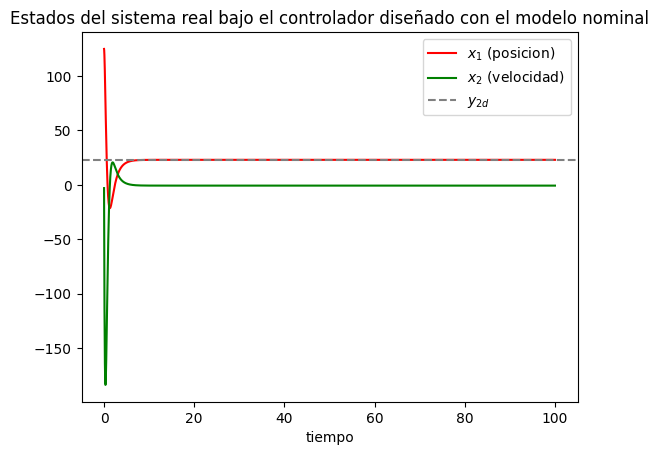

In [10]:
plt.figure(1)
plt.plot(t, log_x[:, 0], 'r', label='$x_1$ (posicion)')
plt.plot(t, log_x[:, 1], 'g', label='$x_2$ (velocidad)')
plt.axhline(y2d, color='gray', linestyle='--', label='$y_{2d}$')
plt.xlabel('tiempo')
plt.title('Estados del sistema real bajo el controlador diseñado con el modelo nominal')
plt.legend()
plt.show()

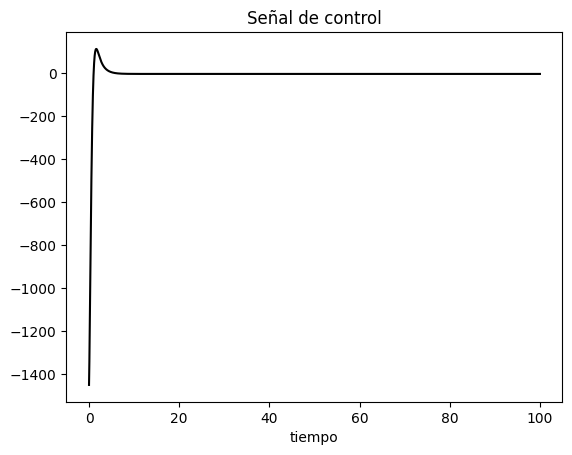

In [11]:
plt.figure(2)
plt.plot(t, log_u[:, 0], 'k')
plt.xlabel('tiempo')
plt.title('Señal de control')
plt.show()

A pesar de que el controlador se diseñó con el modelo nominal $(A,B)$ y se aplica sobre el sistema real $(A_t,B_t)$ ligeramente distinto, la acción integral consigue que $x_1$ converja exactamente al valor deseado $y_{2d}=23$ en régimen permanente — esa es precisamente la robustez que aporta el control integral frente a pequeños errores de modelado, siempre que el sistema real siga siendo estabilizable con la ganancia calculada.